★実行環境の選択

In [40]:
# VSCodeの場合
# edi_flg = 1
# Googlre Colabの場合
edi_flg = 0

In [41]:
import os

repo_path = "/content/My_Python_project"

if edi_flg == 0:
  # GoogleColabにGitHubリポジトリがクローンされていなければ
  # GoogleColabにGitHubリポジトリをクローンする用
  if not os.path.exists(repo_path):
    %cd /content/My_Python_project
    !git clone https://github.com/keiseki-eng/My_Python_project.git
    !git pull origin main



In [42]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [43]:
if edi_flg == 0:
    !pip install japanize-matplotlib

import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import japanize_matplotlib #日本語表示対応
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold


# Notebook から src ディレクトリを追加
# sys.path.append(os.path.join(os.getcwd(), "src"))
sys.path.append("/home/keiseki/My_Python_project/src")

In [44]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [46]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../config/config.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/含水率判定/config.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)

In [47]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']

In [48]:
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

## 02.データ読み込み

In [49]:
# VSCode用
if edi_flg==1:
# ドライブ内のファイルパスを指定
    train_path = '../20.Data/含水率判定/preprocessed_train.pkl'
    df_train = pd.read_pickle(train_path)

# GoogleColab用
elif edi_flg==0:
    # GoogleDriveをマウントしてファイル読み込み準備
    from google.colab import drive
    drive.mount('/content/drive')
    # ドライブ内のファイルパスを指定
    train_path = '/content/My_Python_project/20.Data/含水率判定/preprocessed_train.pkl'
    df_train = pd.read_pickle(train_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
# testデータの読み込み
# VSCode用
if edi_flg==1:
    test_path = '../20.Data/含水率判定/preprocessed_test.pkl'
    df_test = pd.read_pickle(test_path)

# GoogleColab用
elif edi_flg==0:
    # ドライブ内のファイルパスを指定
    test_path = '/content/My_Python_project/20.Data/含水率判定/preprocessed_test.pkl'
    df_test = pd.read_pickle(test_path)

In [51]:
# # 数値列だけ取得
# num_cols = df_train.select_dtypes(include="number").columns
# # 指定特徴量だけ除外
# num_cols = num_cols.drop(["含水率", "sample number", "密度", "針葉樹"])
# # 微分
# df_train_diff = df_train[num_cols].diff(axis=1)

# # 列名変更
# df_train_diff.columns = ["diff_" + c for c in num_cols]

# # 結合
# df_train = pd.concat([df_train, df_train_diff], axis=1)


# # 数値列だけ取得
# # num_cols = df_test.select_dtypes(include="number").columns

# # 微分
# df_test_diff = df_test[num_cols].diff(axis=1)

# # 列名変更
# df_test_diff.columns = ["diff_" + c for c in num_cols]

# # 結合
# df_test = pd.concat([df_test, df_test_diff], axis=1)

# feature_list = feature_list + list(df_train_diff.columns)

In [52]:
# スペクトル平均などの特徴量作成

# 数値列だけ取得
num_cols = df_train.select_dtypes(include="number").columns
# 指定特徴量だけ除外
num_cols = num_cols.drop(["含水率", "sample number", "密度", "針葉樹"])

spec_cols = num_cols  # スペクトル列

df_train["spec_mean"] = df_train[spec_cols].mean(axis=1)
df_train["spec_std"] = df_train[spec_cols].std(axis=1)
df_train["spec_max"] = df_train[spec_cols].max(axis=1)
df_train["spec_min"] = df_train[spec_cols].min(axis=1)

df_test["spec_mean"] = df_test[spec_cols].mean(axis=1)
df_test["spec_std"] = df_test[spec_cols].std(axis=1)
df_test["spec_max"] = df_test[spec_cols].max(axis=1)
df_test["spec_min"] = df_test[spec_cols].min(axis=1)

# 特徴量リストに追加
feature_list = feature_list + ["spec_mean", "spec_std", "spec_max", "spec_min"]

In [53]:
# 水吸収と関係の深い周波数帯を作成
df_train["water_band_5200"] = df_train.loc[:, "5303.52402": "5102.95438",].mean(axis=1)
df_train["water_band_6900"] = df_train.loc[:,  "7000.65171":"6800.08207"].mean(axis=1)
df_train["water_band_8300"] = df_train.loc[:, "8400.78205":"8200.21241"].mean(axis=1)

df_test["water_band_5200"] = df_test.loc[:, "5303.52402": "5102.95438",].mean(axis=1)
df_test["water_band_6900"] = df_test.loc[:,  "7000.65171":"6800.08207"].mean(axis=1)
df_test["water_band_8300"] = df_test.loc[:, "8400.78205":"8200.21241"].mean(axis=1)

feature_list = feature_list + ["water_band_5200", "water_band_6900", "water_band_8300"]

In [54]:
# 経過時間特徴量を樹種ごとに設定
df_train["経過時間"] = df_train.groupby("樹種").cumcount()
df_test["経過時間"] = df_test.groupby("樹種").cumcount()

feature_list = feature_list + ["経過時間"]

/tmp/ipykernel_3243/2396692838.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train["経過時間"] = df_train.groupby("樹種").cumcount()
/tmp/ipykernel_3243/2396692838.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test["経過時間"] = df_test.groupby("樹種").cumcount()


In [55]:
# 主成分分析による特徴量削減
from sklearn.decomposition import PCA

spec_cols = num_cols

pca = PCA(n_components=20)

train_pca = pca.fit_transform(df_train[spec_cols])
test_pca = pca.transform(df_test[spec_cols])

for i in range(20):
    df_train[f"pca_{i}"] = train_pca[:, i]
    df_test[f"pca_{i}"] = test_pca[:, i]

# # df_trainとtestを上書き
df_train = df_train.drop(spec_cols, axis=1)
df_test = df_test.drop(spec_cols, axis=1)

# feature_listから生スペクトルを除外
feature_list = [c for c in feature_list if c not in spec_cols]

# ★trainとtestで樹種が全然違う気がする！　学習時点から樹種を見ないのも一手か・・・？

## interaction特徴量を追加

In [56]:
# df_train["unit_area_x_walk_distance1"] = df_train["unit_area"] * df_train["walk_distance1"]
# df_train["unit_area_x_addr_te"]    = df_train["unit_area"] * df_train["addr1+2_TE"]
# df_test["unit_area_x_walk_distance1"] = df_test["unit_area"] * df_test["walk_distance1"]
# df_test["unit_area_x_addr_te"]    = df_train["unit_area"] * df_test["addr1+2_TE"]

In [57]:
# feature_list = feature_list + ["pseudo_price_band"]
# feature_list = feature_list + ["addr1+2_TE"]
# feature_list = feature_list + ["unit_area_x_walk_distance1"]
# feature_list = feature_list + ["unit_area_x_addr_te"]
# categorical_cols = categorical_cols + ["pseudo_price_band"]


## 05.train/valid 分割　＆　target加工

＿★サンプルウェイトを価格帯別に調整可能とする

In [58]:
# X_all, X_train, X_validの再構築
X_all = df_train[feature_list]
y_all = df_train["含水率"]

# # log変換前の元価格を保存（後段の重み付け用）
# y_price_raw = df_train.loc[X_all.index, "含水率"]

# unit_areaも対数変換
# X_all["unit_area"] = np.log1p(X_all["unit_area"])

# df_train["unit_area"] = np.log1p(df_train["unit_area"])



# 目的変数が右に裾野が広いので対数変換
# y_all = np.log1p(y_all)


# X_train, X_valid, y_train, y_valid, w_train, w_valid = train_test_split(X_all, y_all, df_train["sample_weight"], test_size=0.2, random_state=42)
# X_train, X_valid, y_train, y_valid = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
groups = df_train["樹種"]

gkf = GroupKFold(n_splits=5)

for train_idx, valid_idx in gkf.split(X_all, y_all, groups):

    X_train = X_all.iloc[train_idx]
    X_valid = X_all.iloc[valid_idx]

    y_train = y_all.iloc[train_idx]
    y_valid = y_all.iloc[valid_idx]

    break

## 06.樹種カラム他をカテゴリデータ化

In [59]:
# cat_cols = ["species number", "樹種", "科目"]
cat_cols = ["科目"]

for c in cat_cols:
    X_train[c] = X_train[c].astype("category")

    X_valid[c] = pd.Categorical(
        X_valid[c],
        categories=X_train[c].cat.categories
    )

    df_test[c] = pd.Categorical(
        df_test[c],
        categories=X_train[c].cat.categories
    )

/tmp/ipykernel_3243/962646404.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[c] = X_train[c].astype("category")
/tmp/ipykernel_3243/962646404.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid[c] = pd.Categorical(


## 07.モデル学習

In [60]:
# カスタム評価関数（eval_metric形式）
def mape_eval(preds, train_data):
    y_true = (train_data.get_label())
    y_pred = (preds)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-7))) * 100
    return 'mape', mape, False


In [61]:
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    # weight=w_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)

In [62]:
# モデルの学習
model = lgb.train(params,
                  lgb_train,
                  valid_sets=[lgb_train, lgb_test],
                  feval=mape_eval,  # ← カスタム評価関数を指定
                  callbacks=[lgb.early_stopping(stopping_rounds=1000, verbose=False)
                  ]) #early_stoppingあり

## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

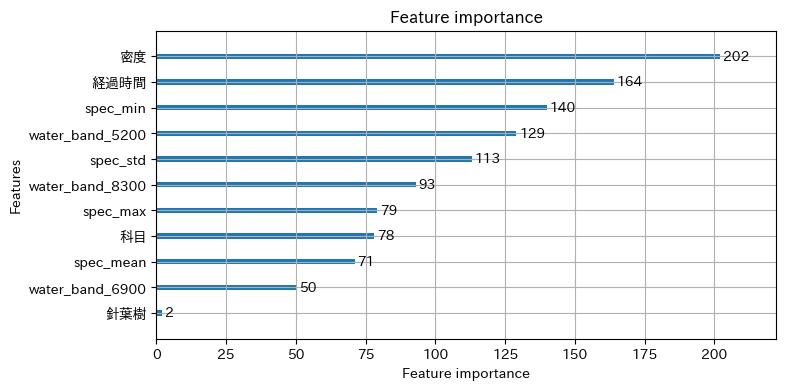

In [63]:
# テストデータで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [64]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [65]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [66]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


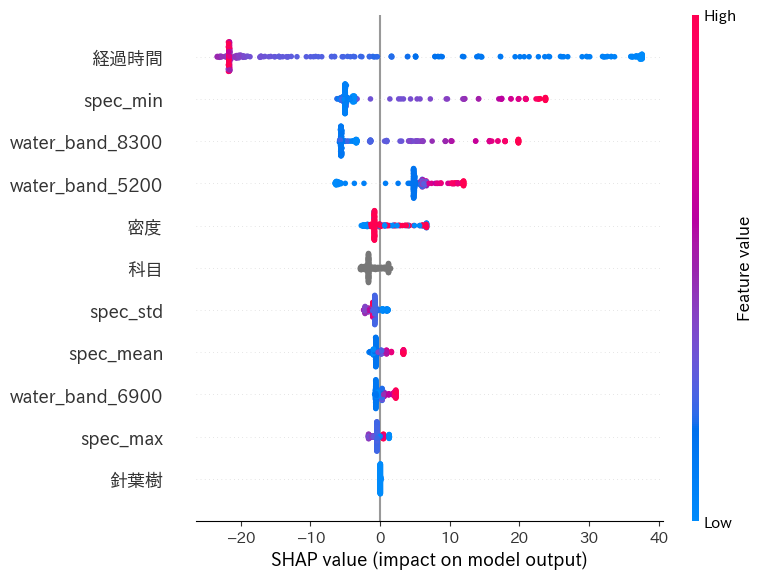

In [67]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

# ★テストデータと学習データで樹種が全然違うから、ワンホットエンコーディングの結果のカラムが違うんだ！　⇨　とりあえずベースラインではconfigでワンホットエンコーディングを消しとこう・・・

In [68]:
# df_trainとdf_testのカラムの差分を確認したい
train_cols = set(X_train.columns)
test_cols  = set(df_test.columns)

# trainにあってtestにない
print("Only in train:")
print(train_cols - test_cols)

# testにあってtrainにない
print("\nOnly in test:")
print(test_cols - train_cols)

Only in train:
set()

Only in test:
{'pca_16', 'pca_9', 'pca_12', 'pca_5', 'pca_1', 'sample number', 'pca_2', 'pca_17', 'pca_19', 'pca_11', 'pca_8', 'pca_6', 'pca_14', 'pca_13', 'pca_15', 'pca_10', '樹種', 'pca_7', 'pca_18', 'pca_0', 'pca_4', 'species number', 'pca_3'}


In [69]:
# 特徴量の選定
# df_test_p = df_test[feature_list].copy()

# 予測
y_scores_submit = model.predict(df_test[feature_list])

# print(y_scores_submit)

In [70]:
#提出用csvの作成
df_scores_submit = pd.DataFrame(y_scores_submit)
df_submit = pd.concat([df_test["sample number"], df_scores_submit], axis=1)

df_submit.to_csv("submit.csv", index=False, header=False)



## 誤差要因分析

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<Axes: ylabel='Frequency'>

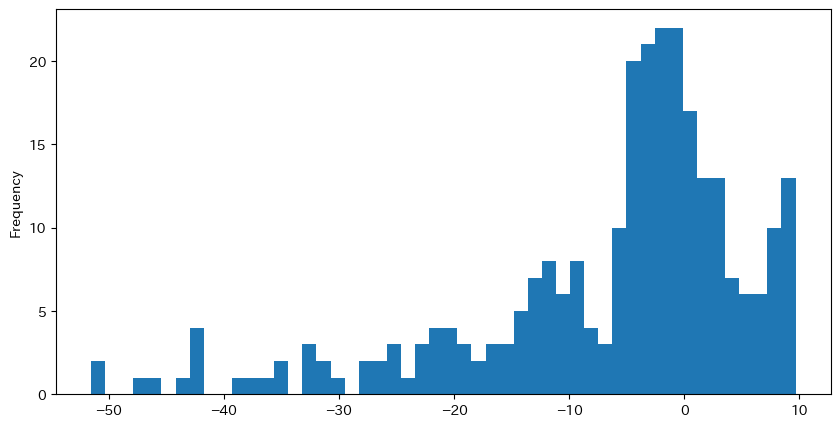

In [72]:
# valid予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)


df_eval = X_valid.copy()
df_eval["y_true"] = y_valid
df_eval["y_pred"] = y_pred_valid

# APE計算（0割防止）
df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# 上位ワースト確認
# df_eval.sort_values("ape", ascending=False).head(20)
df_eval["スコア差分"] = df_eval["y_true"] - df_eval["y_pred"]
df_eval["スコア差分"].plot.hist(bins=50, figsize=(10,5))

In [73]:
def compare_distribution(col):
    return pd.DataFrame({
        "train": df_train[col].describe(),
        "valid": X_valid[col].describe()
    })

# compare_distribution("money_rimawari_now")


In [74]:
# APEが大きい上位10%
threshold = df_eval["ape"].quantile(0.9)
bad_samples = df_eval[df_eval["ape"] >= threshold]

# SHAP値抽出
shap_values_valid = explainer.shap_values(X_valid)
shap_df = pd.DataFrame(
    shap_values_valid,
    columns=X_valid.columns,
    index=X_valid.index
)


# 悪いサンプルのSHAP平均
shap_df.loc[bad_samples.index].abs().mean().sort_values(ascending=False).head(10)


,0
経過時間,14.974183
water_band_5200,6.353942
water_band_8300,5.476265
spec_min,5.454873
科目,1.593409
密度,1.429657
spec_std,1.173743
spec_max,0.950493
spec_mean,0.617279
water_band_6900,0.457399


In [75]:
# shap.force_plot(base_value=explainer.expected_value, shap_values=shap_values, features=X_train)

In [76]:
def calc_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-7))) * 100


# valid 予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)


# MAPE 出力
valid_mape = calc_mape(y_valid, y_pred_valid)
print(f"VALID MAPE: {valid_mape:.4f}%")


VALID MAPE: 27.0151%


In [77]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# df_eval = X_valid.copy()
# df_eval["unit_area"] = np.expm1(df_eval["unit_area"])
# df_eval["y_true"] = y_valid
# df_eval["y_pred"] = y_pred_valid
# df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# # 上位10%の誤差サンプル抽出
# threshold = df_eval["ape"].quantile(0.9)
# bad_samples = df_eval[df_eval["ape"] >= threshold]

# # 調査対象の特徴量リスト
# check_features = [
#     "unit_area",
#     "post1",
#     "floor_plan_code",
#     "walk_distance1",
#     "walk_distance2",
# ]

# # タグ系カラムを抽出（feature_list に基づく）
# tag_features = [col for col in feature_list if col.startswith("tag_")]
# check_features.extend(tag_features)

# # 1. 数値特徴量の誤差 vs 値域の関係
# num_features = ["unit_area", "walk_distance1", "walk_distance2"]
# for col in num_features:
#     plt.figure(figsize=(8,4))
#     sns.scatterplot(data=df_eval, x=col, y="ape", alpha=0.3)
#     sns.scatterplot(data=bad_samples, x=col, y="ape", color="red", alpha=0.5)
#     plt.title(f"{col} と予測誤差(APE)の関係")
#     plt.ylabel("APE")
#     plt.xlabel(col)
#     plt.show()

# # 2. カテゴリ特徴量の誤差分布（箱ひげ図）
# cat_features = ["post1", "floor_plan_code"]
# for col in cat_features:
#     plt.figure(figsize=(10,4))
#     sns.boxplot(x=col, y="ape", data=df_eval)
#     plt.title(f"{col} ごとの予測誤差(APE)分布")
#     plt.xticks(rotation=45)
#     plt.show()

# # 3. タグ系特徴量の影響（悪いサンプルと全体比較）
# for col in tag_features:
#     if col not in df_eval.columns:
#         continue
#     mean_all = df_eval[col].mean()
#     mean_bad = bad_samples[col].mean()
#     print(f"{col}: 全体平均={mean_all:.3f}, 誤差上位10%平均={mean_bad:.3f}")
